<a href="https://colab.research.google.com/" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Colab"></a>

# MatterGen
MatterGen proposes candidate crystal structures. It does not prove stability, synthesizability, or experimental performance. Promising structures should be relaxed and validated after generation.


## Paper link

Main paper: [A generative model for inorganic materials design](https://www.nature.com/articles/s41586-025-08628-5), Nature, 2025.

Preprint: [MatterGen: a generative model for inorganic materials design](https://arxiv.org/abs/2312.03687).

Official code and model checkpoints: [microsoft/mattergen](https://github.com/microsoft/mattergen).




## Diffusion in Crystals

MatterGen does not only move atoms. It denoises three coupled parts of a periodic crystal at the same time:

<figure>
  <img src="https://www.microsoft.com/en-us/research/wp-content/uploads/2025/01/illustrative_blog.png" alt="MatterGen reverse diffusion process for crystal generation" style="max-width: 100%; border: 1px solid #ddd; border-radius: 8px;">
  <figcaption style="font-size: 0.9em; color: #555;">
    Source: Microsoft Research MatterGen blog, Figure 2. It illustrates reverse diffusion from random crystal-like states toward generated materials, including conditional generation.
  </figcaption>
</figure>

The simple schematic below is the idea to keep in mind during the demo:

<svg viewBox="0 0 980 260" width="100%" role="img" aria-label="Crystal diffusion schematic" style="border:1px solid #ddd; border-radius:8px; background:white;">
  <defs>
    <marker id="arrow" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse">
      <path d="M 0 0 L 10 5 L 0 10 z" fill="#555"></path>
    </marker>
  </defs>
  <text x="40" y="36" font-size="22" font-family="Arial" fill="#222">Forward corruption during training</text>
  <text x="610" y="36" font-size="22" font-family="Arial" fill="#222">Reverse denoising during generation</text>
  <rect x="40" y="64" width="210" height="128" rx="10" fill="#eef7f1" stroke="#65a67a"></rect>
  <text x="72" y="92" font-size="18" font-family="Arial" fill="#173b24">Stable crystal</text>
  <circle cx="88" cy="138" r="13" fill="#2a9d8f"></circle>
  <circle cx="135" cy="120" r="13" fill="#e76f51"></circle>
  <circle cx="182" cy="152" r="13" fill="#2a9d8f"></circle>
  <path d="M70 170 L210 170 L220 98 L86 98 Z" fill="none" stroke="#333" stroke-width="2"></path>
  <line x1="265" y1="128" x2="420" y2="128" stroke="#555" stroke-width="3" marker-end="url(#arrow)"></line>
  <rect x="440" y="64" width="210" height="128" rx="10" fill="#f7f1ee" stroke="#d08b72"></rect>
  <text x="483" y="92" font-size="18" font-family="Arial" fill="#4a1f13">Noisy crystal</text>
  <circle cx="493" cy="149" r="13" fill="#aaa"></circle>
  <circle cx="551" cy="108" r="13" fill="#777"></circle>
  <circle cx="608" cy="164" r="13" fill="#bbb"></circle>
  <path d="M470 176 L615 165 L625 84 L488 102 Z" fill="none" stroke="#777" stroke-width="2" stroke-dasharray="7 5"></path>
  <line x1="665" y1="128" x2="820" y2="128" stroke="#555" stroke-width="3" marker-end="url(#arrow)"></line>
  <rect x="780" y="64" width="160" height="128" rx="10" fill="#eef3fb" stroke="#6a8fc7"></rect>
  <text x="807" y="92" font-size="18" font-family="Arial" fill="#1d345c">Generated</text>
  <text x="820" y="116" font-size="18" font-family="Arial" fill="#1d345c">candidate</text>
  <circle cx="826" cy="154" r="13" fill="#2a9d8f"></circle>
  <circle cx="870" cy="132" r="13" fill="#e76f51"></circle>
  <circle cx="906" cy="166" r="13" fill="#2a9d8f"></circle>
  <path d="M810 180 L925 175 L914 112 L824 106 Z" fill="none" stroke="#333" stroke-width="2"></path>
  <text x="93" y="226" font-size="16" font-family="Arial" fill="#555">atom types + positions + lattice</text>
  <text x="437" y="226" font-size="16" font-family="Arial" fill="#555">randomized elements, coordinates, cell</text>
  <text x="789" y="226" font-size="16" font-family="Arial" fill="#555">denoised crystal proposal</text>
</svg>


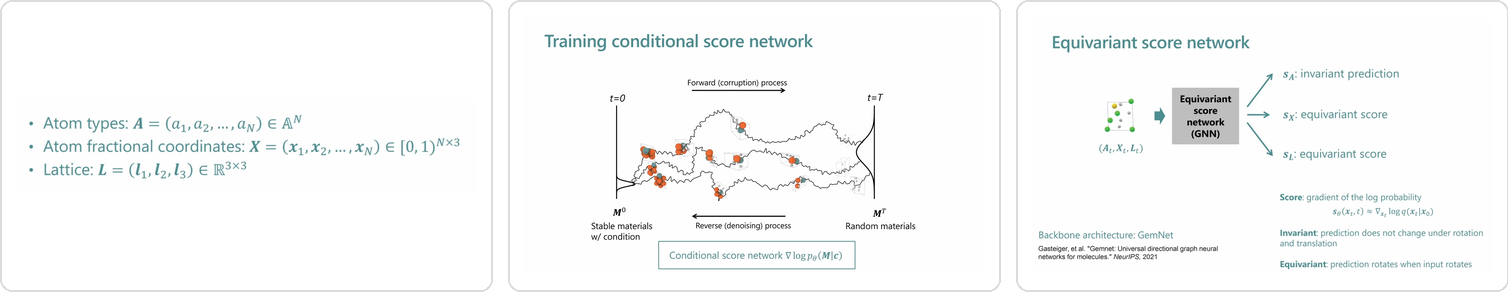

In [1]:
#@title Denoising { display-mode: "form" }
import base64
from IPython.display import Image, display
display(Image(data=base64.b64decode('...')))


In [2]:
#@title Helper functions. Run this cell once, then ignore it. { display-mode: "form" }
import io
import json
import os
import re
import shlex
import shutil
import subprocess
import sys
import zipfile
from datetime import datetime
from pathlib import Path

REPO_DIR = Path("/content/mattergen")
ENV_DIR = Path("/content/mattergen-env")
RESULTS_ROOT = Path("/content/mattergen-results")
RESULTS_ROOT.mkdir(exist_ok=True)

def check_gpu():
    try:
        subprocess.run(["nvidia-smi"], check=True)
    except Exception:
        print("No GPU was found. In Colab, choose Runtime -> Change runtime type -> T4 GPU.")

def setup_mattergen():
    global ENV_PYTHON, MATTERGEN_GENERATE

    if not (REPO_DIR / "pyproject.toml").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/microsoft/mattergen.git", str(REPO_DIR)],
            check=True,
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
        )

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
    uv = shutil.which("uv")
    if uv is None:
        raise RuntimeError("uv was not found. Restart Colab and run again.")

    ENV_PYTHON = ENV_DIR / "bin" / "python"
    if not ENV_PYTHON.exists():
        subprocess.run([uv, "venv", str(ENV_DIR), "--python", "3.10"], check=True)

    subprocess.run([uv, "pip", "install", "--python", str(ENV_PYTHON), "-e", str(REPO_DIR)], check=True)
    MATTERGEN_GENERATE = ENV_DIR / "bin" / "mattergen-generate"
    print("MatterGen is ready:", MATTERGEN_GENERATE)

def install_visualisation_tools():
    packages = ["pymatgen", "ase<=3.25.0", "py3Dmol", "ipywidgets", "matplotlib"]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)
    try:
        from google.colab import output as colab_output
        colab_output.enable_custom_widget_manager()
    except Exception:
        pass
    print("Visualisation tools are ready.")

def download_model(model_name):
    script = (
        "from mattergen.common.utils.data_classes import MatterGenCheckpointInfo; "
        f"MatterGenCheckpointInfo.from_hf_hub({model_name!r}); "
        f"print('Downloaded {model_name}')"
    )
    subprocess.run([str(ENV_PYTHON), "-c", script], cwd=str(REPO_DIR), check=True)

def safe_label(text):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(text)).strip("_").lower()

def generate_material(model, condition=None, guidance=0.0, label=None, trajectories=False, seed=42):
    condition = condition or {}
    download_model(model)

    label = label or model
    output_dir = RESULTS_ROOT / f"{datetime.now():%Y%m%d_%H%M%S}_{safe_label(label)}"
    output_dir.mkdir(parents=True, exist_ok=True)

    script = "\n".join([
        "import random",
        "import numpy as np",
        "import torch",
        "from mattergen.scripts.generate import main",
        "",
        f"seed = {int(seed)}",
        "random.seed(seed)",
        "np.random.seed(seed)",
        "torch.manual_seed(seed)",
        "if torch.cuda.is_available():",
        "    torch.cuda.manual_seed(seed)",
        "    torch.cuda.manual_seed_all(seed)",
        "",
        "main(",
        f"    output_path={str(output_dir)!r},",
        f"    pretrained_name={model!r},",
        "    batch_size=1,",
        "    num_batches=1,",
        f"    properties_to_condition_on={condition!r},",
        f"    diffusion_guidance_factor={float(guidance)!r},",
        f"    record_trajectories={bool(trajectories)!r},",
        ")",
    ])

    print(f"Generating with seed = {int(seed)}")
    print("Results folder:", output_dir)
    subprocess.run([str(ENV_PYTHON), "-c", script], cwd=str(REPO_DIR), check=True)
    print("Results:", output_dir)
    return output_dir

def first_cif(results_dir):
    from pymatgen.core import Structure

    archive = Path(results_dir) / "generated_crystals_cif.zip"
    if not archive.exists():
        raise FileNotFoundError(f"Missing file: {archive}")

    with zipfile.ZipFile(archive) as zf:
        names = sorted(name for name in zf.namelist() if name.lower().endswith(".cif"))
        cif_text = zf.read(names[0]).decode("utf-8")

    return names[0], Structure.from_str(cif_text, fmt="cif"), cif_text

def show_material(results_dir):
    import py3Dmol

    name, structure, cif_text = first_cif(results_dir)
    print("File:", name)
    print("Formula:", structure.composition.reduced_formula)
    print("Number of sites:", len(structure))
    print("Lattice a,b,c:", tuple(round(x, 3) for x in structure.lattice.abc))
    print("Angles:", tuple(round(x, 2) for x in structure.lattice.angles))

    view = py3Dmol.view(width=850, height=560)
    view.addModel(cif_text, "cif")
    view.setStyle({"sphere": {"scale": 0.30}, "stick": {"radius": 0.12}})
    view.addUnitCell()
    view.replicateUnitCell(2, 2, 2)
    view.setBackgroundColor("white")
    view.zoomTo()
    return view.show()

def load_trajectory(results_dir):
    import ase.io

    archive = Path(results_dir) / "generated_trajectories.zip"
    if not archive.exists():
        raise FileNotFoundError("This result has no trajectory. Generate with trajectories=True.")

    with zipfile.ZipFile(archive) as zf:
        names = sorted(name for name in zf.namelist() if name.lower().endswith(".extxyz"))
        text = zf.read(names[0]).decode("utf-8")

    return ase.io.read(io.StringIO(text), index=":", format="extxyz"), names[0]

def show_trajectory(results_dir, max_frames=80, interval_ms=500):
    import ase.io
    import ipywidgets as widgets
    import numpy as np
    import py3Dmol
    from IPython.display import clear_output, display
    from pymatgen.io.ase import AseAtomsAdaptor

    frames, name = load_trajectory(results_dir)
    steps = np.unique(np.linspace(0, len(frames) - 1, min(max_frames, len(frames)), dtype=int))
    sampled = [frames[i] for i in steps]

    play = widgets.Play(value=0, min=0, max=len(sampled) - 1, step=1, interval=interval_ms, repeat=False)
    slider = widgets.IntSlider(value=0, min=0, max=len(sampled) - 1, description="Frame", readout=False)
    widgets.link((play, "value"), (slider, "value"))

    status = widgets.HTML()
    out = widgets.Output()
    last = {"frame": None}

    def draw(i):
        if last["frame"] == i:
            return
        last["frame"] = i
        atoms = sampled[i]
        structure = AseAtomsAdaptor.get_structure(atoms)
        status.value = f"<b>{name}</b> | frame {i + 1}/{len(sampled)} | stored step {int(steps[i])}/{len(frames) - 1}"

        with out:
            clear_output(wait=True)
            view = py3Dmol.view(width=850, height=540)
            view.addModel(structure.to(fmt="cif"), "cif")
            view.setStyle({"sphere": {"scale": 0.30}, "stick": {"radius": 0.12}})
            view.addUnitCell()
            view.setBackgroundColor("white")
            view.zoomTo()
            view.show()

    slider.observe(lambda change: draw(change["new"]), names="value")
    play.observe(lambda change: draw(change["new"]), names="value")
    display(widgets.VBox([widgets.HBox([play, slider]), status, out]))
    draw(0)
    return {"play": play, "slider": slider, "frames": frames}

def plot_cell_evolution(results_dir):
    import matplotlib.pyplot as plt
    import numpy as np

    frames, name = load_trajectory(results_dir)
    steps = np.arange(len(frames))
    lengths = np.array([atoms.cell.lengths() for atoms in frames])
    volumes = np.array([atoms.get_volume() for atoms in frames])

    plt.figure(figsize=(10, 4))
    plt.plot(steps, lengths[:, 0], label="a")
    plt.plot(steps, lengths[:, 1], label="b")
    plt.plot(steps, lengths[:, 2], label="c")
    plt.plot(steps, volumes / max(volumes), label="volume / max(volume)")
    plt.xlabel("Trajectory step")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.title("Cell evolution during denoising")
    plt.show()


## 1. Download Model

Run this once. It installs MatterGen, installs the visualisation tools, and downloads the base model.

`DEMO_SEED` makes the generated examples repeatable. Change it to any integer to get a different pair of generated materials.


In [3]:
DEMO_SEED = 42
check_gpu()
setup_mattergen()
install_visualisation_tools()
download_model("mattergen_base")


MatterGen is ready: /content/mattergen-env/bin/mattergen-generate
Visualisation tools are ready.


## 2. Unconditional Generation

This asks MatterGen to generate one inorganic crystal without giving it a target property.


In [4]:
UNCONDITIONAL_RESULTS = generate_material(
    model="mattergen_base",
    label="unconditional_demo",
    seed=DEMO_SEED,
)


Generating with seed = 42
Results folder: /content/mattergen-results/20260728_031254_unconditional_demo
Results: /content/mattergen-results/20260728_031254_unconditional_demo


## 3. Visualise the Unconditional Material

This shows the final generated crystal structure.


In [5]:
show_material(UNCONDITIONAL_RESULTS)


File: gen_0.cif
Formula: MgInF6
Number of sites: 8
Lattice a,b,c: (5.17, 5.167, 5.844)
Angles: (63.65, 63.65, 59.94)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 4. Conditional Generation

This asks MatterGen for one material with a target band gap of 3.0 eV.
To try a different target, edit only the first two lines in the next code cell.

Other easy substitutions:

| Goal | Model | Condition |
|---|---|---|
| Band gap | `dft_band_gap` | `{"dft_band_gap": 3.0}` |
| Space group | `space_group` | `{"space_group": 225}` |
| Magnetic density | `dft_mag_density` | `{"dft_mag_density": 0.15}` |
| Bulk modulus | `ml_bulk_modulus` | `{"ml_bulk_modulus": 400.0}` |
| Chemical system | `chemical_system` | `{"chemical_system": "Li-O"}` |


In [6]:
CONDITIONAL_MODEL = "dft_band_gap"
CONDITION = {"dft_band_gap": 3.0}
CONDITIONAL_RESULTS = generate_material(
    CONDITIONAL_MODEL, CONDITION, guidance=2.0, label="band_gap_demo", trajectories=True, seed=DEMO_SEED
)


Generating with seed = 42
Results folder: /content/mattergen-results/20260728_031501_band_gap_demo
Results: /content/mattergen-results/20260728_031501_band_gap_demo


## 5. Visualise the Conditional Material

This shows the final crystal generated from the conditional run.


In [7]:
show_material(CONDITIONAL_RESULTS)


File: gen_0.cif
Formula: SrO4F3
Number of sites: 8
Lattice a,b,c: (4.214, 4.218, 9.264)
Angles: (76.69, 76.79, 60.11)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 6. Trajectory Visualisation

This animation shows how MatterGen denoised the conditional sample into the final material above.


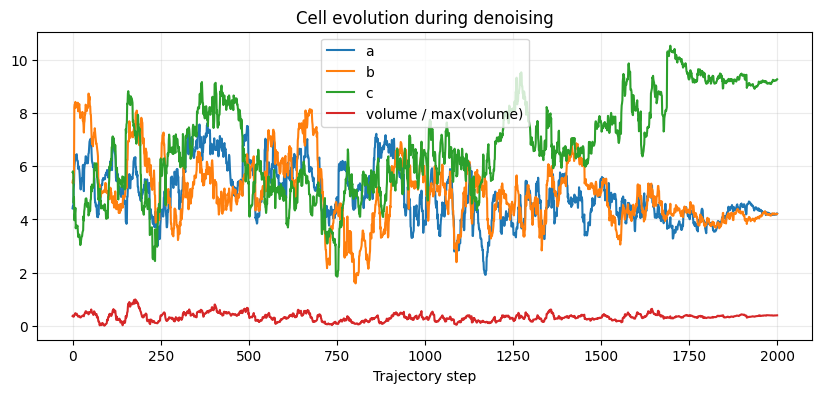

In [8]:
show_trajectory(CONDITIONAL_RESULTS)
plot_cell_evolution(CONDITIONAL_RESULTS)


## Download Results

Run this if you want ZIP files containing the generated CIF files and trajectory.


In [9]:
from google.colab import files
for folder in [UNCONDITIONAL_RESULTS, CONDITIONAL_RESULTS]:
    zip_path = shutil.make_archive(str(Path("/content") / folder.name), "zip", root_dir=str(folder))
    files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>